## Import All The Libraries


In [2]:
from sklearn.preprocessing import StandardScaler  
from sklearn.model_selection import train_test_split  
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import copy
import torch
import tqdm

# Format and Adjust Data

In [3]:
df = pd.read_csv("dataset.csv")

# One Hot Encoding the 'stock' column
df = pd.get_dummies(df, columns=['stock'])

# remove data leaking columns
df.pop('next_weeks_open') 
df.pop('percent_change_next_weeks_price')

# Replace missing values
cols = ['previous_weeks_volume','percent_change_volume_over_last_wk']
df[cols] = df[cols].replace('?',0)

# Handle Date Column's String Type 
df['date'] = pd.to_datetime(df['date'])
# Distribute Date into new columns
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
# Pop old 'date' column, we have month,day,year to represent its values
temp_date = df.pop('date')

# Convert all dollar values from string into floats
df = df.replace('\$','',regex=True).astype(float)

# Shift label column to rightmost for eash of indexing 

# Move new target to end
y_col = df.pop('next_weeks_close')
df.insert(len(df.columns), 'next_weeks_close', y_col)

<>:24: SyntaxWarning: invalid escape sequence '\$'
<>:24: SyntaxWarning: invalid escape sequence '\$'
/var/folders/16/22h86xpd7j33w8md_8shh5gh0000gn/T/ipykernel_79406/2910099702.py:24: SyntaxWarning: invalid escape sequence '\$'
  df = df.replace('\$','',regex=True).astype(float)


## Scale the dataset

In [ ]:
# Convert dataframe to numpy
data = df.to_numpy()

# Split into features and labels
X = data[:, :-1]
y = data[:, -1].reshape(-1, 1)

# Now fit scalers ONLY on training data
x_scalar = StandardScaler()
y_scalar = StandardScaler()

X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.2, shuffle=True, random_state=42)

X_train = x_scalar.fit_transform(X_train)
X_val = x_scalar.transform(X_val)
X_test = x_scalar.transform(X_test)

y_train = y_scalar.fit_transform(y_train)
y_val = y_scalar.transform(y_val)
y_test = y_scalar.transform(y_test)

# Convert all splits to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32).reshape(-1, 1)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

# Create NN Models 

In [20]:
# Model 1: Simple 1-hidden-layer NN
model1 = nn.Sequential(
    nn.Linear(44, 32),
    nn.ReLU(),
    nn.Linear(32, 1)
)

# Model 2: 2 layers with dropout and mixed activations
model2 = nn.Sequential(
    nn.Linear(44, 32),
    nn.ELU(),
    nn.Dropout(0.3),
    nn.Linear(32, 16),
    nn.Tanh(),
    nn.Linear(16, 1)
)

# Model 3: Deeper, mild regularization
model3 = nn.Sequential(
    nn.Linear(44, 64),
    nn.ReLU(),
    nn.Linear(64, 32),
    nn.ELU(),
    nn.Dropout(0.2),
    nn.Linear(32, 1)
)

# Train Models

In [21]:
import torch.nn.functional as F
from sklearn.metrics import r2_score
import pandas as pd

results = []

def train_model(model, X_train, y_train, X_val, y_val, l2_val, y_scalar, model_name="Model"):
    n_epochs = 500
    batch_size = 32
    loss_fn = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=l2_val)

    for epoch in range(n_epochs):
        model.train()
        permutation = torch.randperm(X_train.size()[0])
        for i in range(0, X_train.size()[0], batch_size):
            indices = permutation[i:i+batch_size]
            X_batch, y_batch = X_train[indices], y_train[indices]

            y_pred = model(X_batch)
            loss = loss_fn(y_pred, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # Evaluate after final epoch
    model.eval()
    with torch.no_grad():
        y_pred_train = model(X_train).detach().numpy()
        y_pred_val = model(X_val).detach().numpy()

        y_pred_train_unscaled = y_scalar.inverse_transform(y_pred_train)
        y_train_unscaled = y_scalar.inverse_transform(y_train.numpy())

        y_pred_val_unscaled = y_scalar.inverse_transform(y_pred_val)
        y_val_unscaled = y_scalar.inverse_transform(y_val.numpy())

        train_r2 = r2_score(y_train_unscaled, y_pred_train_unscaled)
        val_r2 = r2_score(y_val_unscaled, y_pred_val_unscaled)

        train_mse = loss_fn(torch.tensor(y_pred_train), y_train).item()
        val_mse = loss_fn(torch.tensor(y_pred_val), y_val).item()

        best_metrics = {
            "model": model_name,
            "l2_val": l2_val,
            "train_mse": train_mse,
            "val_mse": val_mse,
            "train_r2": train_r2,
            "val_r2": val_r2
        }

    return best_metrics

# Create Evaluation Model 

# Test different regularization values and models

In [22]:
def run_regularization_experiments(models, weight_decay_values):
    all_results = []

    for i in range(len(models)):
        for weight_decay in weight_decay_values:
            model_name = f"model_{i}"
            print(f"\n=== Training {model_name} ===")

            metrics = train_model(models[i], X_train, y_train, X_val, y_val, weight_decay,y_scalar, model_name=model_name)
            all_results.append(metrics)

    return all_results

# Run tests

In [23]:
weight_decay_values = [0, 1e-4, 1e-3, 1e-2, 0.1, 1.0, 5.0, 10.0]
models = [model1,model2,model3]

results = run_regularization_experiments(models, weight_decay_values)
    
df_results = pd.DataFrame(results)
df_results.to_csv("regression_results.csv", index=False)
print("Saved to regression_results.csv")


=== Training model_0 ===

=== Training model_0 ===

=== Training model_0 ===

=== Training model_0 ===

=== Training model_0 ===

=== Training model_0 ===

=== Training model_0 ===

=== Training model_0 ===

=== Training model_1 ===

=== Training model_1 ===

=== Training model_1 ===

=== Training model_1 ===

=== Training model_1 ===

=== Training model_1 ===

=== Training model_1 ===

=== Training model_1 ===

=== Training model_2 ===

=== Training model_2 ===

=== Training model_2 ===

=== Training model_2 ===

=== Training model_2 ===

=== Training model_2 ===

=== Training model_2 ===

=== Training model_2 ===
Saved to regression_results.csv


# Plotting results 

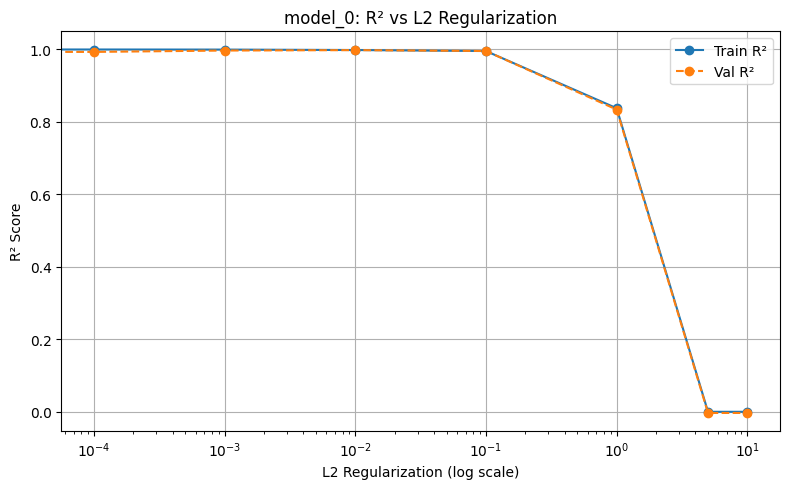

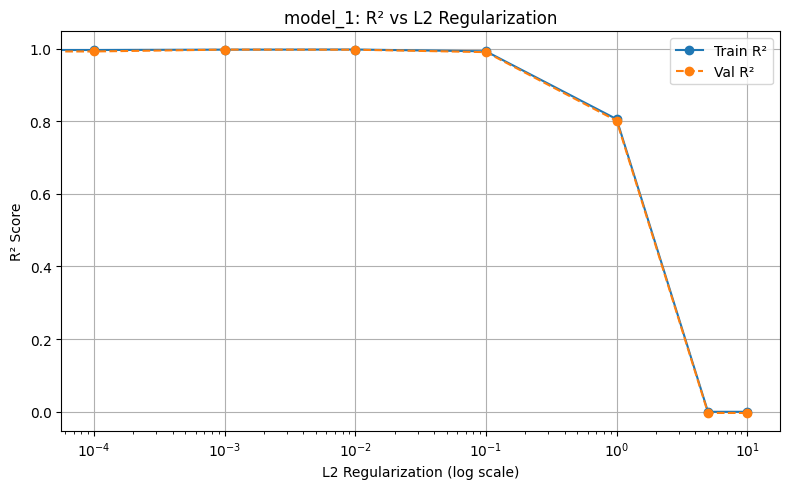

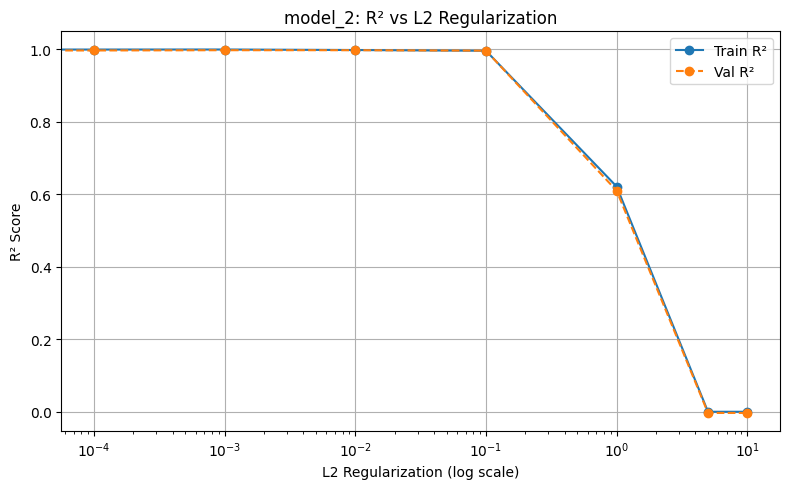

In [24]:
# # # print(df_results)

# Loop through base model names
for model_index in [0, 1, 2]:
    # Select only rows for this model
    model_name = f"model_{model_index}"
    subset = df_results[df_results['model'].str.contains(model_name)]
    
    # Sort by L2 value to keep lines clean
    subset = subset.sort_values(by='l2_val')
    
    plt.figure(figsize=(8, 5))
    
    # Plot train and val R² with markers
    plt.plot(subset['l2_val'], subset['train_r2'], marker='o', label='Train R²')
    plt.plot(subset['l2_val'], subset['val_r2'], marker='o', linestyle='--', label='Val R²')

    plt.xscale('log')
    plt.xlabel('L2 Regularization (log scale)')
    plt.ylabel('R² Score')
    plt.title(f"{model_name}: R² vs L2 Regularization")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()